Data

In [1]:
################################################################################
#  1) INSTALL AND IMPORTS
################################################################################
# !pip install --upgrade pip  # (Optional) upgrade pip
# !pip install mamba-ssm      # Install Mamba from PyPI

import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error

################################################################################
#  2) READ CSV
################################################################################

train_df = pd.read_csv('~/data/Germany_time_zone/all/train_with_all.csv')
test_df = pd.read_csv('~/data/Germany_time_zone/all/test_with_all.csv')



train_df['ds'] = pd.to_datetime(train_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Check date ranges
print("First date in train_df:", train_df['ds'].min())
print("Last date in train_df:", train_df['ds'].max())
print("First date in test_df:", test_df['ds'].min())
print("Last date in test_df:", test_df['ds'].max())

calendar_features = ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 
                     'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend']
gas_price_features = ['gas_price']
load_features = ['load', 'co2_emission_allowances', 'synthetic_price']
renewable_features = ['renewable', 'non_renewable']
cross_border_features = ['cross_border_trading']

# Define the exogenous variable lists
stat_exog_list = [] 
hist_exog_list = (
    calendar_features
    + gas_price_features
    + load_features
    # + renewable_features
    # + cross_border_features
)

futr_exog_list = (
    calendar_features
)

First date in train_df: 2018-10-01 00:00:00
Last date in train_df: 2023-12-31 23:00:00
First date in test_df: 2024-01-01 00:00:00
Last date in test_df: 2024-12-31 23:00:00


In [2]:
test_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,...,day_of_week_cos,hour_sin,hour_cos,gas_price,cross_border_trading,non_renewable,renewable,load,co2_emission_allowances,synthetic_price
0,2024-01-01 00:00:00,0.10,electricity_prices,0,1,0,0,1,0.5,0.866025,...,1.0,0.000000,1.000000,31.574,-11728.9125,8378.536596,41778.25343,40170.0900,66.6,84.047273
1,2024-01-01 01:00:00,0.01,electricity_prices,0,1,1,0,1,0.5,0.866025,...,1.0,0.258819,0.965926,31.574,-11129.9725,8284.442818,41522.96191,38818.1500,66.6,84.047273
2,2024-01-01 02:00:00,0.00,electricity_prices,0,1,2,0,1,0.5,0.866025,...,1.0,0.500000,0.866025,31.574,-11635.4075,8282.031575,41346.84615,37847.5650,66.6,84.047273
3,2024-01-01 03:00:00,-0.01,electricity_prices,0,1,3,0,1,0.5,0.866025,...,1.0,0.707107,0.707107,31.574,-11492.7000,8318.301450,40363.41746,37123.2325,66.6,84.047273
4,2024-01-01 04:00:00,-0.03,electricity_prices,0,1,4,0,1,0.5,0.866025,...,1.0,0.866025,0.500000,31.574,-10593.8850,8309.993639,40234.70911,36753.5150,66.6,84.047273


In [3]:


################################################################################
#  4) DEFINE THE MAMBA MODEL
################################################################################
from mamba_ssm import Mamba

class MambaForecaster(nn.Module):
    """
    - horizon (h): how many steps to forecast (24)
    - input_size: how many past time steps we feed in (e.g., 24*7)
    - exog_size: how many exogenous features per time step
    - d_model, d_state, etc.: Mamba hyperparameters
    """
    def __init__(
        self,
        horizon=24,
        input_size=168,        # e.g. 7 days if hourly 24*7
        exog_size=0,           # how many exogenous features
        d_model=32,
        d_state=16,
        d_conv=4,
        expand=2,
    ):
        super().__init__()
        self.horizon = horizon
        self.input_size = input_size
        self.exog_size = exog_size
        self.d_model   = d_model
        
        # We will embed (input_size + exog_size) "past features" into d_model dimension
        # For each time step in the past, we might have 1 "y" + exog_size. 
        # We'll keep it simple: flatten all past steps into a single vector:
        # shape = (batch_size, input_size*(1+exog_size)).
        # Then we linearly transform to d_model before feeding into Mamba.
        
        total_in_features = (input_size) + (input_size * exog_size)
        
        self.input_proj = nn.Linear(total_in_features, d_model)
        
        # A single Mamba block
        self.mamba_block = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand,
        )
        
        # Output: from Mamba hidden dimension -> horizon
        self.out_proj = nn.Linear(d_model, horizon)
        
    def forward(self, past_y, past_exog):
        """
        Inputs:
          past_y:    shape (batch_size, input_size)
          past_exog: shape (batch_size, input_size, exog_size)
          
        Returns:
          forecast: shape (batch_size, horizon)
        """
        batch_size = past_y.shape[0]
        
        # Flatten exogenous: (batch_size, input_size, exog_size) -> (batch_size, input_size*exog_size)
        past_exog_flat = past_exog.reshape(batch_size, -1)
        
        # Combine main series + exog into one vector
        # shape = (batch_size, input_size + input_size*exog_size)
        combined_input = torch.cat([past_y, past_exog_flat], dim=1)
        
        # Project to d_model
        x = self.input_proj(combined_input)  # (batch_size, d_model)
        
        # We want to interpret dimension 1 as "sequence length" for Mamba
        # But here we have only shape (batch_size, d_model). 
        # So let's treat it as if seq_len=1, dim=d_model.
        x = x.unsqueeze(1)  # (batch_size, 1, d_model)
        
        # Pass through Mamba (it expects shape (B, L, d_model)), returns same shape
        hidden = self.mamba_block(x)  # (batch_size, 1, d_model)
        
        # We only have L=1 in this design, so we take hidden[:, -1, :] if we had a longer L
        hidden = hidden[:, 0, :]  # (batch_size, d_model)
        
        # Finally project to horizon
        forecast = self.out_proj(hidden)  # (batch_size, horizon)
        
        return forecast


In [4]:

################################################################################
#  5) PREPARE TENSORS AND DATALOADERS
################################################################################

# For a day-ahead approach:
#  - horizon = 24
#  - input_size = 24*7 (7 days)
HORIZON = 24
INPUT_SIZE = 24*7

# We will create a function that, given a DataFrame with 'y' and exogs,
# returns rolling samples: each sample is (past_y, past_exog) -> next 24 hours of y
# For simplicity, we won't do fancy train/val splits, just produce raw pairs.

def make_dataset(df, input_size=INPUT_SIZE, horizon=HORIZON, exog_cols=None):
    """
    Creates (X,y) pairs from a time-based DataFrame. We assume df is chronological.
    exog_cols: list of columns to use as exogenous features.
    
    Returns lists of:
      past_y_list: shape (num_samples, input_size)
      past_exog_list: shape (num_samples, input_size, len(exog_cols))
      future_y_list: shape (num_samples, horizon)  # for training
      future_time_stamps: the ds times for the forecast horizon
    """
    if exog_cols is None:
        exog_cols = []
    
    arr_y = df['y'].values
    arr_exog = df[exog_cols].values if exog_cols else None
    
    timestamps = df['ds'].values
    
    samples = []
    
    # We can only form a sample if we have at least input_size past points
    # plus horizon future points. We'll do a rolling approach.
    for i in range(len(df) - input_size - horizon):
        past_y    = arr_y[i : i+input_size]
        future_y  = arr_y[i+input_size : i+input_size+horizon]
        
        if arr_exog is not None:
            past_exog = arr_exog[i : i+input_size, :]
        else:
            past_exog = np.zeros((input_size, 0))
        
        # We'll store the future timestamps, too, if we want them for analysis
        future_ts = timestamps[i+input_size : i+input_size+horizon]
        
        samples.append((past_y, past_exog, future_y, future_ts))
    
    return samples

# Prepare training dataset from train_df
train_data = train_df.sort_values('ds').reset_index(drop=True)
train_samples = make_dataset(
    train_data,
    input_size=INPUT_SIZE,
    horizon=HORIZON,
    exog_cols=hist_exog_list
)

# Convert them to PyTorch Tensors
X_past_y      = []
X_past_exog   = []
Y_future      = []

for (past_y, past_exog, future_y, _) in train_samples:
    X_past_y.append(past_y)
    X_past_exog.append(past_exog)
    Y_future.append(future_y)

X_past_y      = torch.tensor(X_past_y,      dtype=torch.float32)
X_past_exog   = torch.tensor(X_past_exog,   dtype=torch.float32)
Y_future      = torch.tensor(Y_future,      dtype=torch.float32)

# We'll store them in a simple TensorDataset
train_dataset = torch.utils.data.TensorDataset(X_past_y, X_past_exog, Y_future)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

################################################################################
#  6) INSTANTIATE AND TRAIN THE MAMBA MODEL
################################################################################

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

model = MambaForecaster(
    horizon=HORIZON,
    input_size=INPUT_SIZE,
    exog_size=len(hist_exog_list),
    d_model=32,
    d_state=16,
    d_conv=4,
    expand=2,
).to(device)

criterion = nn.L1Loss()  # MAE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

max_epochs = 50  # increase as needed
model.train()

for epoch in range(1, max_epochs+1):
    total_loss = 0.0
    for batch in train_loader:
        past_y, past_exog, y_true = batch
        past_y     = past_y.to(device)
        past_exog  = past_exog.to(device)
        y_true     = y_true.to(device)
        
        optimizer.zero_grad()
        y_pred = model(past_y, past_exog)  # shape (batch_size, horizon)
        
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * past_y.size(0)
    
    epoch_loss = total_loss / len(train_loader.dataset)
    if epoch % 1 == 0:
        print(f"Epoch {epoch}/{max_epochs}, MAE loss: {epoch_loss:.4f}")


Using device: cuda


/scratch/slurm_tmpdir/job_25200888/ipykernel_762372/2035301324.py:73: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  X_past_y      = torch.tensor(X_past_y,      dtype=torch.float32)


Epoch 1/50, MAE loss: 4046131063434.4995
Epoch 2/50, MAE loss: 189619.8907
Epoch 3/50, MAE loss: 64898.1888
Epoch 4/50, MAE loss: 50019.5544
Epoch 5/50, MAE loss: 42136.3631
Epoch 6/50, MAE loss: 35750.5350
Epoch 7/50, MAE loss: 31456.1379
Epoch 8/50, MAE loss: 27179.6520
Epoch 9/50, MAE loss: 23833.5882
Epoch 10/50, MAE loss: 20385.5390
Epoch 11/50, MAE loss: 17969.2783
Epoch 12/50, MAE loss: 15924.4030
Epoch 13/50, MAE loss: 13827.7737
Epoch 14/50, MAE loss: 11920.0299
Epoch 15/50, MAE loss: 10051.9065
Epoch 16/50, MAE loss: 8845.0471
Epoch 17/50, MAE loss: 7790.2003
Epoch 18/50, MAE loss: 5987.0115
Epoch 19/50, MAE loss: 4946.4400
Epoch 20/50, MAE loss: 3665.6976
Epoch 21/50, MAE loss: 2641.7853
Epoch 22/50, MAE loss: 1691.3290
Epoch 23/50, MAE loss: 857.7582
Epoch 24/50, MAE loss: 390.7710
Epoch 25/50, MAE loss: 252.3127
Epoch 26/50, MAE loss: 154.9990
Epoch 27/50, MAE loss: 100.7098
Epoch 28/50, MAE loss: 75.6421
Epoch 29/50, MAE loss: 61.6158
Epoch 30/50, MAE loss: 48.1485
Epoch 

In [5]:

################################################################################
#  7) DAY-BY-DAY PREDICTION ON TEST SET
################################################################################
# We replicate your approach, generating day-by-day forecasts and collecting them.

test_data = test_df.sort_values('ds').reset_index(drop=True)

# For day-by-day prediction, we do something like:
#  - For each day in the test range, we take the preceding 'input_size' hours from test_data
#    (which simulates we have real data up to that point),
#  - Then we do a single forward pass and predict the next 24 hours.
#
# We'll store the predictions in a DataFrame with columns ['ds', 'y_pred', 'y_actual'].

model.eval()

test_predictions = []
time_stamps = test_data['ds'].values

# We'll step through test_data in daily increments
# But we must ensure we have enough "history" = input_size hours
# We'll define a date range that leaves room for those input_size hours plus horizon
start_ts = test_data['ds'].min()
end_ts   = test_data['ds'].max()

# We can do something similar to your NBEATS example using a "daily" loop.
# Because the test set might overlap with the training set, you can do an approach
# that uses the last part of train data if needed. For simplicity, we'll only use test_data.

dates_for_forecast = pd.date_range(start=start_ts, end=end_ts - pd.Timedelta(hours=INPUT_SIZE+HORIZON), freq='24H')

for current_day in dates_for_forecast:
    # We'll locate the "history" block from current_day to current_day + input_size
    # Actually we need the *previous* input_size hours, so we define an index range
    # from (current_day - input_size hours) to (current_day).
    
    window_start = current_day
    window_end   = current_day + pd.Timedelta(hours=INPUT_SIZE-1)
    forecast_start = current_day + pd.Timedelta(hours=INPUT_SIZE)
    forecast_end   = current_day + pd.Timedelta(hours=INPUT_SIZE + HORIZON - 1)
    
    # Filter test_data for the "history" portion
    hist_mask = (test_data['ds'] >= window_start) & (test_data['ds'] <= window_end)
    hist_slice = test_data[hist_mask].copy()
    
    # We only proceed if we have exactly 'INPUT_SIZE' hours
    if len(hist_slice) != INPUT_SIZE:
        continue
    
    # Filter test_data for the "future" portion
    futr_mask = (test_data['ds'] >= forecast_start) & (test_data['ds'] <= forecast_end)
    futr_slice = test_data[futr_mask].copy()
    
    if len(futr_slice) != HORIZON:
        # If we don't have exactly 24 hours, skip
        continue
    
    # Prepare model inputs
    past_y    = torch.tensor(hist_slice['y'].values, dtype=torch.float32).unsqueeze(0).to(device)
    past_exog = torch.tensor(hist_slice[hist_exog_list].values, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Forward pass
    with torch.no_grad():
        y_pred = model(past_y, past_exog).cpu().numpy().flatten()  # shape (24,)
    
    # Store predictions
    for i in range(HORIZON):
        test_predictions.append({
            'ds': futr_slice.iloc[i]['ds'],
            'y_pred': y_pred[i],
            'y_actual': futr_slice.iloc[i]['y']
        })

forecast_df = pd.DataFrame(test_predictions).sort_values('ds').reset_index(drop=True)



In [6]:

################################################################################
#  8) METRICS
################################################################################
mae  = mean_absolute_error(forecast_df['y_actual'], forecast_df['y_pred'])
mse  = mean_squared_error(forecast_df['y_actual'], forecast_df['y_pred'])
rmse = np.sqrt(mse)

print("Model Performance (Mamba):")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Day-of-week breakdown
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
forecast_df['day_of_week'] = forecast_df['ds'].dt.dayofweek

metrics_by_day = {}
for day in range(7):
    day_data = forecast_df[forecast_df['day_of_week'] == day]
    if len(day_data) == 0:
        continue
    mae_day  = mean_absolute_error(day_data['y_actual'], day_data['y_pred'])
    mse_day  = mean_squared_error(day_data['y_actual'], day_data['y_pred'])
    rmse_day = np.sqrt(mse_day)
    metrics_by_day[day] = {'MAE': mae_day, 'MSE': mse_day, 'RMSE': rmse_day}

metrics_df = pd.DataFrame(metrics_by_day).T
print("\nMetrics by Day of the Week:")
print(metrics_df)

Model Performance (Mamba):
MAE:  57.10
MSE:  5316.59
RMSE: 72.91

Metrics by Day of the Week:
         MAE          MSE       RMSE
0  59.874577  4989.625938  70.637284
1  63.307510  6088.137227  78.026516
2  66.334203  7893.840780  88.847289
3  64.069805  8538.851476  92.405906
4  57.363142  4403.391622  66.358056
5  46.001998  2797.223204  52.888781
6  42.085785  2392.412612  48.912295


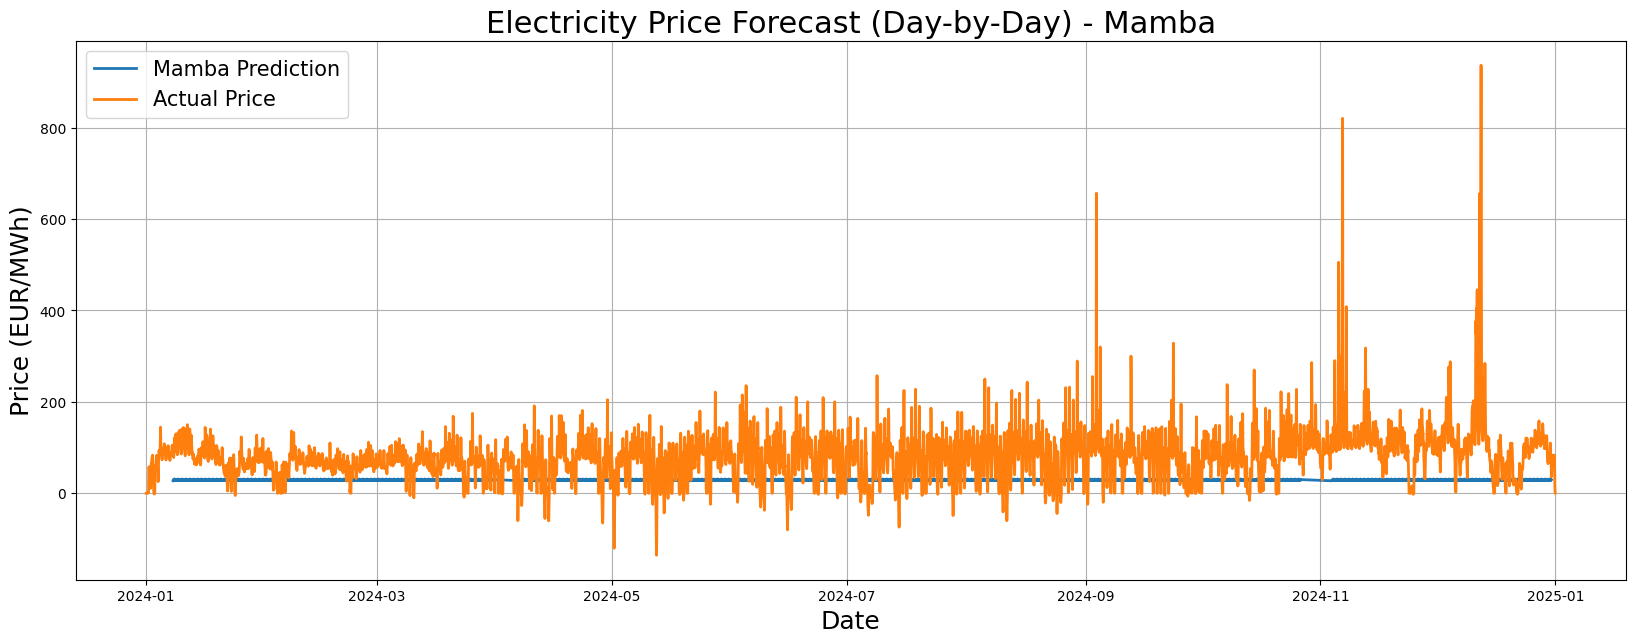

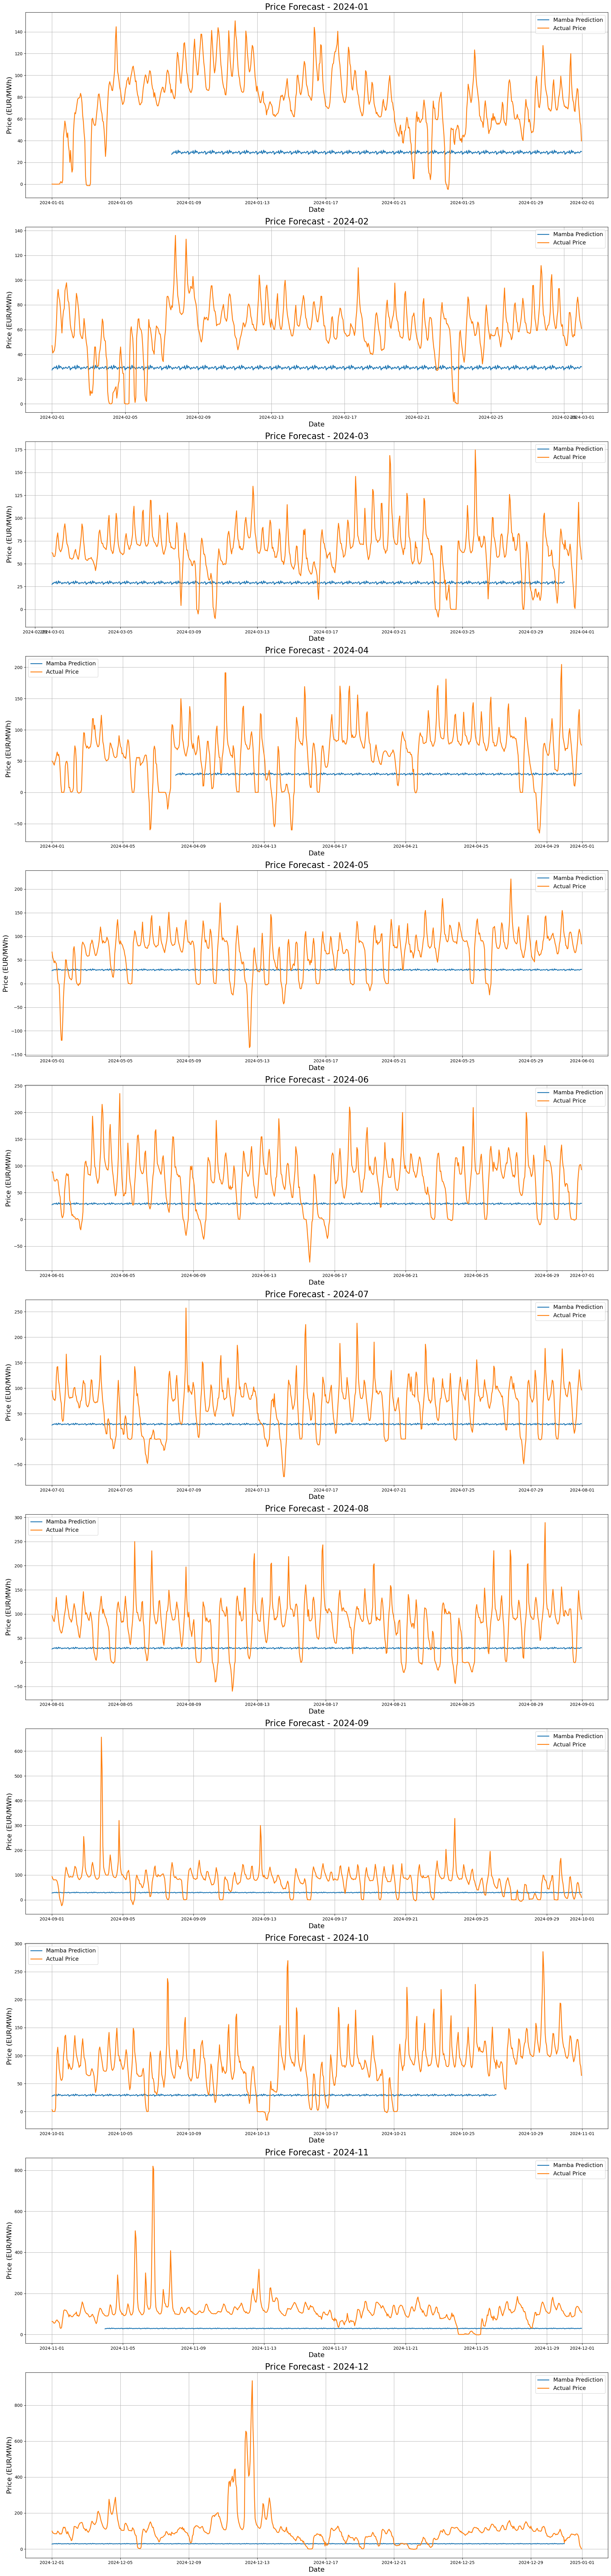

,ds,y_pred,y_actual,day_of_week,month_period
0,2024-01-08 00:00:00,27.367838,87.02,0,2024-01
1,2024-01-08 01:00:00,28.765968,84.32,0,2024-01
2,2024-01-08 02:00:00,28.414408,81.82,0,2024-01
3,2024-01-08 03:00:00,29.750658,79.11,0,2024-01
4,2024-01-08 04:00:00,29.511681,78.48,0,2024-01
5,2024-01-08 05:00:00,28.844580,82.10,0,2024-01
6,2024-01-08 06:00:00,30.746859,94.30,0,2024-01
7,2024-01-08 07:00:00,28.028030,111.10,0,2024-01
8,2024-01-08 08:00:00,28.836023,121.11,0,2024-01
9,2024-01-08 09:00:00,31.259232,117.83,0,2024-01


In [7]:

################################################################################
#  9) PLOTS
################################################################################

# 9.1: Single overall forecast
fig, ax = plt.subplots(figsize=(20, 7))
ax.plot(forecast_df['ds'], forecast_df['y_pred'], label='Mamba Prediction', linewidth=2)
# Plot actual
test_plot_df = test_data[['ds','y']].copy()
test_plot_df = test_plot_df.set_index('ds')
ax.plot(test_plot_df.index, test_plot_df['y'], label='Actual Price', linewidth=2)

ax.set_title('Electricity Price Forecast (Day-by-Day) - Mamba', fontsize=22)
ax.set_ylabel('Price (EUR/MWh)', fontsize=18)
ax.set_xlabel('Date', fontsize=18)
ax.legend(prop={'size': 15})
ax.grid()
plt.show()

# 9.2: Plot each month separately
forecast_df['month_period'] = forecast_df['ds'].dt.to_period('M')
unique_months = forecast_df['month_period'].unique()

fig, axes = plt.subplots(len(unique_months), 1, figsize=(20, 7*len(unique_months)))
if len(unique_months) == 1:
    axes = [axes]  # force array

for i, month_val in enumerate(unique_months):
    ax = axes[i]
    sub_pred = forecast_df[forecast_df['month_period'] == month_val]
    sub_test = test_plot_df[test_plot_df.index.to_period('M') == month_val]
    
    ax.plot(sub_pred['ds'], sub_pred['y_pred'], label='Mamba Prediction', linewidth=2)
    ax.plot(sub_test.index, sub_test['y'], label='Actual Price', linewidth=2)
    ax.set_title(f'Price Forecast - {month_val}', fontsize=20)
    ax.set_ylabel('Price (EUR/MWh)', fontsize=16)
    ax.set_xlabel('Date', fontsize=16)
    ax.legend(prop={'size': 13})
    ax.grid()

plt.tight_layout()
plt.show()

# Display a small preview of the final forecast DataFrame
forecast_df.head(10)